# 05. Modelagem de Classificação: Regressão Logística Binária

**Documentação da Etapa**
* **Objetivo da etapa:** Desenvolver e avaliar modelos de regressão logística binária ($Y \in \{0, 1\}$) sob estimação por máxima verossimilhança para responder a duas frentes analíticas de comércio exterior das rotas líderes:
  1. **Regressão Logística Simples:** Avaliar se o volume físico de uma operação permite distinguir e predizer o sentido da operação ($\text{Fluxo} \sim \text{Quilograma Líquido}$, onde $1 = \text{Exportação}$ e $0 = \text{Importação}$).
  2. **Regressão Logística Múltipla:** Identificar os determinantes estruturais do crescimento anual do faturamento comercial ($\text{Crescimento\_binário} \sim \text{Município} + \text{País} + \text{Categoria\_SH4} + \text{Quilograma Líquido}$, onde $1 = \text{Valor FOB cresceu no ano } t \text{ vs. } t-1$ e $0 = \text{caiu ou manteve}$).
* **Dados de entrada:** Base com as rotas líderes por cidade e fluxo (`data/processed/df_rotas_lideres.csv`).
* **Procedimentos realizados:**
  1. Configuração do ambiente e importação das rotinas modulares de classificação em `R/regressao_logistica.R`.
  2. Codificação da variável dependente para o modelo simples (`Fluxo` em binário: $1 = \text{Exportação}$, $0 = \text{Importação}$).
  3. Ajuste do modelo logístico simples ($\text{Fluxo} \sim \text{Quilograma Líquido}$), cálculo das Razões de Chance (*Odds Ratios* — $e^{\beta}$), do Ponto de Virada ($x^* = -\beta_0/\beta_1$) e traçado da curva sigmoide em S.
  4. Construção da variável resposta para o modelo múltiplo (`Crescimento_binário`), pareando o valor FOB do ano $t$ com o ano $t-1$ por série de produto (SH4), município e país de destino/origem, com classificação das mercadorias em categorias (*Commodity* vs. *Manufaturado*).
  5. Ajuste do modelo logístico múltiplo ($\text{Crescimento\_binário} \sim \text{Município} + \text{País} + \text{Categoria\_SH4} + \text{Quilograma Líquido}$) e extração dos efeitos marginais via *Odds Ratios*.
  6. Avaliação de desempenho de ambos os classificadores nos três limiares de corte ($c = 0.3$, $c = 0.5$ e $c = 0.7$), gerando Matrizes de Confusão, Acurácia, Precisão, Sensibilidade (*Recall*) e Especificidade.
  7. Construção gráfica da Curva ROC e cálculo da Área sob a Curva (AUC) via concordância para validação da capacidade discriminatória global.

### 0. Configurações e Carregamento de Dados

In [1]:
# ==============================================================================
# Setup, Carregamento de Bibliotecas, Funções e Base de Dados
# ==============================================================================
library(readr)
library(dplyr)
library(stringr)
library(ggplot2)
library(scales)
library(fs)

# 1. Determina dinamicamente o caminho da raiz do projeto
caminho_atual <- getwd()
raiz_projeto <- ifelse(basename(caminho_atual) == "notebooks", path_dir(caminho_atual), caminho_atual)

# 2. Carrega as funções do script modular de regressão logística
source(path(raiz_projeto, "R", "regressao_logistica.R"))

# 3. Carrega a base das rotas líderes tratada
caminho_csv <- path(raiz_projeto, "data", "processed", "df_sazonal_lideres.csv")
dados_rotas <- read_csv2(caminho_csv, show_col_types = FALSE)

# 4. Configuração visual de números no console
options(scipen = 999, digits = 4)

cat(sprintf("Ambiente configurado com sucesso! Base carregada com %d observações.\n", nrow(dados_rotas)))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor




ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.



Ambiente configurado com sucesso! Base carregada com 481 observações.


## 1. Regressão Logística Simples: Fluxo Comercial por Volume Físico

**Conceito e Aplicação Metodológica:**
A **Regressão Logística Binária Simples** modela a probabilidade de ocorrência de uma resposta qualitativa dicotômica ($Y = 1$ para Exportação e $Y = 0$ para Importação) em função do peso físico da carga por meio da função de ligação *Logit*:

$$\ln\left(\frac{P(Y = 1)}{1 - P(Y = 1)}\right) = \beta_0 + \beta_1 \cdot \text{Quilograma\_Líquido} \implies P(Y = 1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 \cdot \text{Quilograma\_Líquido})}}$$

* **O que avalia:** Responde à pergunta de pesquisa se o peso da operação permite distinguir e predizer o sentido do fluxo comercial, estimando a **Razão de Chances** ($\text{Odds Ratio} = e^{\beta_1}$, que expressa o fator multiplicativo sobre as chances de ser exportação a cada acréscimo de peso) e o **Ponto de Virada / Fronteira de Decisão** ($x^* = -\beta_0 / \beta_1$, volume em que $p = 0{,}5$).
* **Aplicação no Projeto:** Ajustada via máxima verossimilhança sobre a base de rotas líderes, permitindo traçar a curva sigmoide em S e avaliar a precisão das classificações por meio de matrizes de confusão sob três limiares de decisão ($c \in \{0{,}3;\ 0{,}5;\ 0{,}7\}$) e Curva ROC/AUC.

In [2]:
# Padronização da variável resposta binária para o modelo simples
dados_rotas$Fluxo_bin <- ifelse(grepl("Exp", as.character(dados_rotas$Fluxo), ignore.case = TRUE), 1L, 0L)
table(Fluxo_Original = dados_rotas$Fluxo, Fluxo_Binario = dados_rotas$Fluxo_bin)

              Fluxo_Binario
Fluxo_Original   0   1
    Exportação   0 240
    Importação 241   0

### Aplicação da Regressão
Ajuste do modelo $P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X)}}$ via `glm(family = binomial)` e extração das Razões de Chance ($e^{\hat{\beta}}$).

In [3]:
# Ajuste do Modelo Logístico Simples
modelo_simples <- ajustar_logistica_simples(dados_rotas)
summary(modelo_simples)

# Sumarização com Odds Ratios
sumarizar_odds_ratios(modelo_simples)


Call:
glm(formula = Fluxo_bin ~ Quilograma_Liquido, family = binomial(link = "logit"), 
    data = df_ajuste)

Coefficients:
                         Estimate     Std. Error z value        Pr(>|z|)    
(Intercept)        -1.13486537219  0.16580141223   -6.84 0.0000000000077 ***
Quilograma_Liquido  0.00000001687  0.00000000242    6.98 0.0000000000030 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 666.81  on 480  degrees of freedom
Residual deviance: 557.40  on 479  degrees of freedom
AIC: 561.4

Number of Fisher Scoring iterations: 6


Termo,Estimativa_Logit,Erro_Padrao,Valor_z,p_valor,Odds_Ratio,CI_2.5,CI_97.5
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
(Intercept),-1.135,0.1658,-6.845,<0.001,0.3215,0.2323,0.4449
Quilograma_Liquido,0.000,0.0000,6.977,<0.001,1.0000,1.0000,1.0000


### Avaliação do Modelo
Matriz de confusão e métricas de desempenho (Acurácia, Precisão, Sensibilidade/Recall e Especificidade) calculadas sob diferentes limiares de decisão ($c \in \{0.3, 0.5, 0.7\}$).

In [4]:
metricas_simples <- avaliar_desempenho_classificacao(modelo_simples, dados_rotas$Fluxo_bin, limiares = c(0.3, 0.5, 0.7))

# Exibição das métricas para os três limiares
for (c_val in names(metricas_simples)) {
  cat("\n================ Limiar c =", c_val, "================\n")
  print(metricas_simples[[c_val]]$Matriz)
  cat("Acurácia:", metricas_simples[[c_val]]$Acuracia, "\n")
  cat("Precisão:", metricas_simples[[c_val]]$Precisao, "\n")
  cat("Recall (Sensibilidade):", metricas_simples[[c_val]]$Recall, "\n")
  cat("Especificidade:", metricas_simples[[c_val]]$Especificidade, "\n")
}


================ Limiar c = 0.3 ================
    Previsto
Real   0   1
   0  31 210
   1  41 199
Acurácia: 0.4782 
Precisão: 0.4866 
Recall (Sensibilidade): 0.8292 
Especificidade: 0.1286 

================ Limiar c = 0.5 ================
    Previsto
Real   0   1
   0 218  23
   1 111 129
Acurácia: 0.7214 
Precisão: 0.8487 
Recall (Sensibilidade): 0.5375 
Especificidade: 0.9046 

================ Limiar c = 0.7 ================
    Previsto
Real   0   1
   0 240   1
   1 153  87
Acurácia: 0.6798 
Precisão: 0.9886 
Recall (Sensibilidade): 0.3625 
Especificidade: 0.9959 


### Diagnósticos e Visualizações
Curva ROC com cálculo da concordância (AUC) e visualização da curva sigmoide em relação à fronteira de decisão $x^* = -\frac{\beta_0}{\beta_1}$.

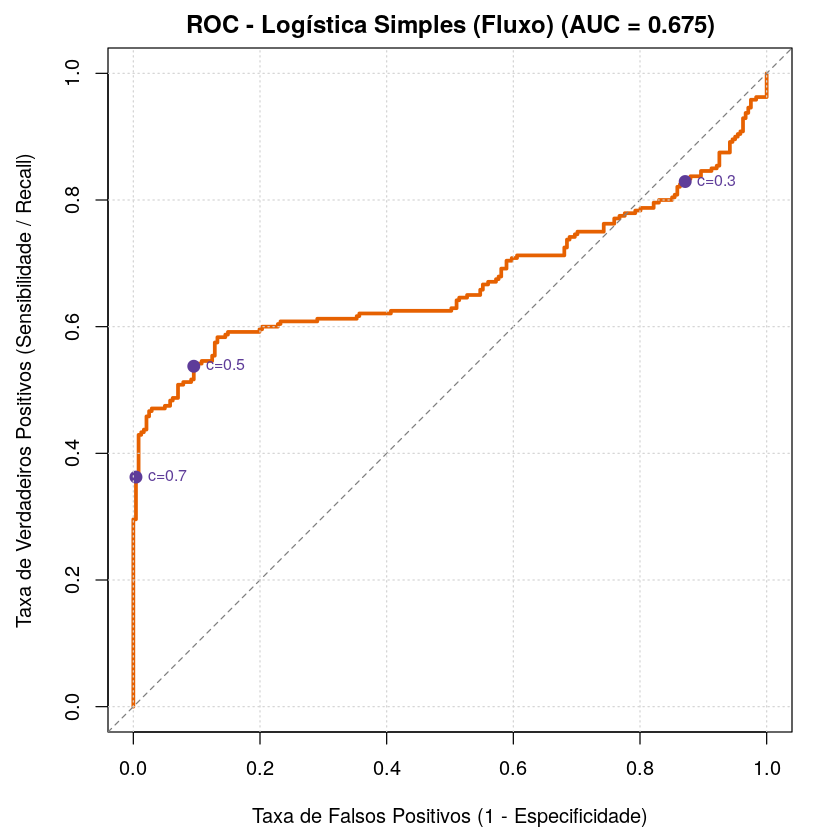

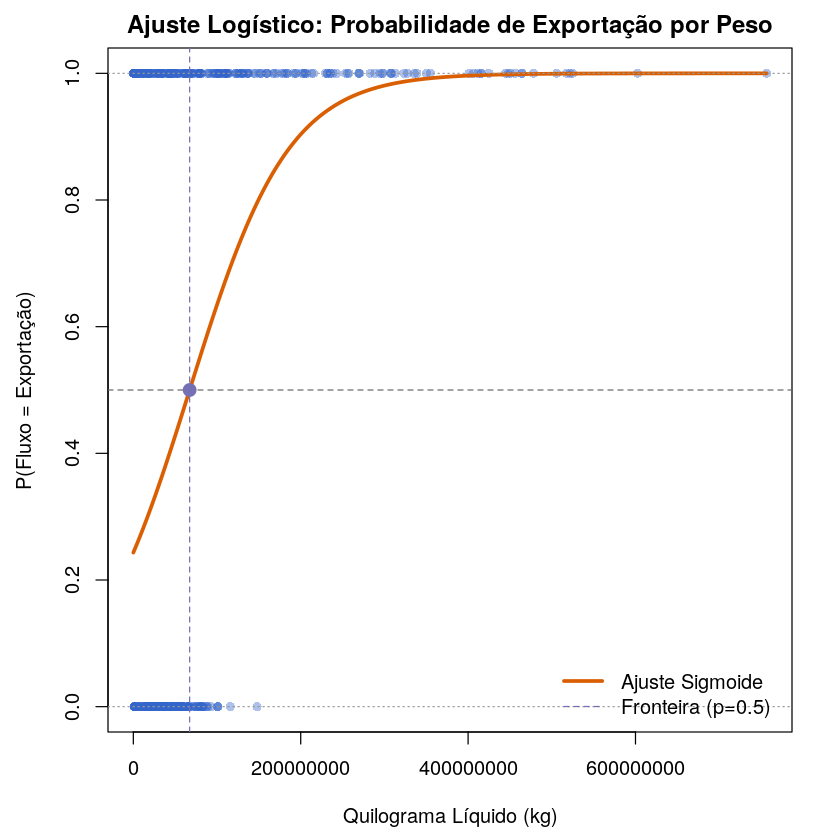

In [5]:
# Curva ROC e AUC
auc_simples <- plotar_curva_roc(modelo_simples, dados_rotas$Fluxo_bin, titulo = "ROC - Logística Simples (Fluxo)")

# Curva Sigmoide e Fronteira de Decisão
plotar_sigmoide_simples(modelo_simples, dados_rotas)

## 2. Regressão Logística Múltipla: Determinantes do Crescimento Anual do Valor FOB

**Conceito e Aplicação Metodológica:**
A **Regressão Logística Binária Múltipla** estende a modelagem Logit para avaliar o efeito conjunto de múltiplos regressores (quantitativos e qualitativos) sobre a probabilidade de ocorrência do evento de interesse ($Y = 1$ para crescimento anual do valor FOB e $Y = 0$ para queda ou estabilidade)[cite: 1]:

$$\ln\left(\frac{P(Y = 1)}{1 - P(Y = 1)}\right) = \beta_0 + \sum_{j=1}^{k} \beta_j X_j \implies P(Y = 1|\mathbf{X}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 \text{Município} + \beta_2 \text{País} + \beta_3 \text{Categoria\_SH4} + \beta_4 \text{Quilograma\_Líquido})}}$$

* **O que avalia:** Identifica quais fatores contextuais (geográficos, de parceiro comercial, setoriais e de escala física) determinam o crescimento do faturamento ano a ano ($t$ vs. $t-1$), isolando o efeito marginal de cada preditor por meio das **Razões de Chance Parciais** ($\text{Odds Ratio}_j = e^{\beta_j}$)[cite: 1].
* **Aplicação no Projeto:** Ajustada via máxima verossimilhança sobre a base de séries temporais de produtos[cite: 1], avaliando a sensibilidade da probabilidade de expansão comercial entre categorias (*Commodity* vs. *Manufaturado*), controlando por volume e praça, com validação de desempenho sob múltiplos pontos de corte ($c \in \{0{,}3;\ 0{,}5;\ 0{,}7\}$)[cite: 1] e capacidade de discriminação global via métrica AUC/ROC[cite: 1].

In [6]:
# Preparação da base com criação de lag temporal e variável resposta binária
dados_crescimento <- preparar_dados_crescimento(dados_rotas)

table(Crescimento_Binario = dados_crescimento$Crescimento_binario)

Crescimento_Binario
 0  1 
19 23 

### Preparação das Variáveis Explicativas
Verificação de distribuições, níveis categóricos (`Município`, `País`, `Categoria_SH4`) e volume (`Quilograma_Líquido`).

In [7]:
summary(dados_crescimento[, c("Municipio", "Pais", "Categoria_SH4", "Quilograma_Liquido")])

        Municipio              Pais         Categoria_SH4 Quilograma_Liquido 
 Cubatão - SP:14   Argentina     : 7   Commodity   :35    Min.   :     7210  
 Guarujá - SP:14   Chile         : 7   Manufaturado: 7    1st Qu.: 18192260  
 Santos - SP :14   China         :21                      Median : 41940580  
                   Estados Unidos: 7                      Mean   : 44178708  
                                                          3rd Qu.: 53515238  
                                                          Max.   :203096336  

### Aplicação da Regressão
Ajuste da equação linear no logit:
$$\text{logit}(p) = \beta_0 + \beta_1 \text{Município} + \beta_2 \text{País} + \beta_3 \text{Categoria\_SH4} + \beta_4 \text{Quilograma\_Líquido}$$

In [8]:
# Ajuste do Modelo Logístico Múltiplo
modelo_multiplo <- ajustar_logistica_multipla(dados_crescimento)
summary(modelo_multiplo)

# Tabela com Odds Ratios (e^beta) e Intervalos de Confiança
tabela_or_multipla <- sumarizar_odds_ratios(modelo_multiplo)
tabela_or_multipla

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = Crescimento_binario ~ Municipio + Pais + Categoria_SH4 + 
    Quilograma_Liquido, family = binomial(link = "logit"), data = df)

Coefficients: (1 not defined because of singularities)
                               Estimate    Std. Error z value Pr(>|z|)  
(Intercept)                -1.872644198   2.784863490   -0.67    0.501  
MunicipioGuarujá - SP     -10.979897926   5.628710067   -1.95    0.051 .
MunicipioSantos - SP      -16.362689737   8.246865596   -1.98    0.047 *
PaisChile                 -15.682843003   7.673252546   -2.04    0.041 *
PaisChina                   1.234942280   2.244013374    0.55    0.582  
PaisEstados Unidos          3.307011691   3.114807944    1.06    0.288  
Categoria_SH4Manufaturado            NA            NA      NA       NA  
Quilograma_Liquido          0.000000338   0.000000166    2.04    0.042 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null dev

Termo,Estimativa_Logit,Erro_Padrao,Valor_z,p_valor,Odds_Ratio,CI_2.5,CI_97.5
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
(Intercept),-1.873,2.785,-0.672,0.5013,0.1537,0.0007,36.0746
MunicipioGuarujá - SP,-10.980,5.629,-1.951,0.0511,0.0000,0.0000,1.0536
MunicipioSantos - SP,-16.363,8.247,-1.984,0.0472,0.0000,0.0000,0.8194
PaisChile,-15.683,7.673,-2.044,0.0410,0.0000,0.0000,0.5254
PaisChina,1.235,2.244,0.550,0.5821,3.4382,0.0423,279.5350
PaisEstados Unidos,3.307,3.115,1.062,0.2884,27.3034,0.0609,12233.3741
Quilograma_Liquido,0.000,0.000,2.038,0.0416,1.0000,1.0000,1.0000


### Avaliação do Modelo
Análise do desempenho de classificação com análise de sensibilidade para diferentes pontos de corte operacionais.

In [9]:
metricas_multipla <- avaliar_desempenho_classificacao(
  modelo_multiplo, 
  dados_crescimento$Crescimento_binario, 
  limiares = c(0.3, 0.5, 0.7)
)

for (c_val in names(metricas_multipla)) {
  cat("\n================ Limiar c =", c_val, "================\n")
  print(metricas_multipla[[c_val]]$Matriz)
  cat("Acurácia:", metricas_multipla[[c_val]]$Acuracia, "\n")
  cat("Precisão:", metricas_multipla[[c_val]]$Precisao, "\n")
  cat("Recall:", metricas_multipla[[c_val]]$Recall, "\n")
  cat("Especificidade:", metricas_multipla[[c_val]]$Especificidade, "\n")
}


================ Limiar c = 0.3 ================
    Previsto
Real  0  1
   0 13  6
   1  1 22
Acurácia: 0.8333 
Precisão: 0.7857 
Recall: 0.9565 
Especificidade: 0.6842 

================ Limiar c = 0.5 ================
    Previsto
Real  0  1
   0 17  2
   1  1 22
Acurácia: 0.9286 
Precisão: 0.9167 
Recall: 0.9565 
Especificidade: 0.8947 

================ Limiar c = 0.7 ================
    Previsto
Real  0  1
   0 18  1
   1  7 16
Acurácia: 0.8095 
Precisão: 0.9412 
Recall: 0.6957 
Especificidade: 0.9474 


### Diagnósticos e Visualizações
Curva ROC global e análise de impacto marginal dos preditores categóricos sobre as probabilidades estimadas de crescimento do valor FOB.

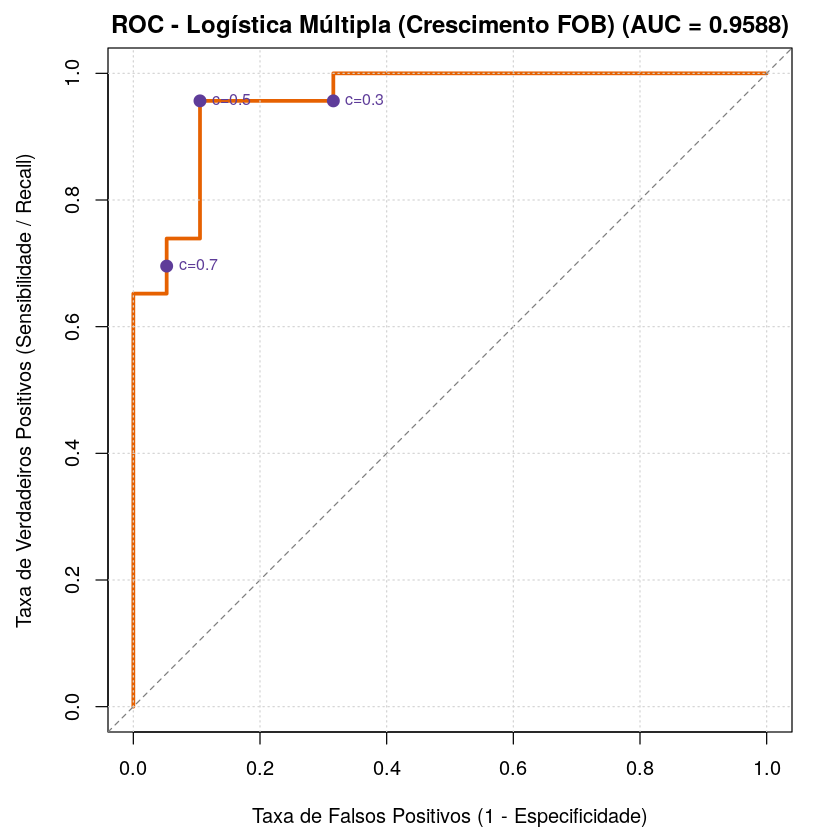

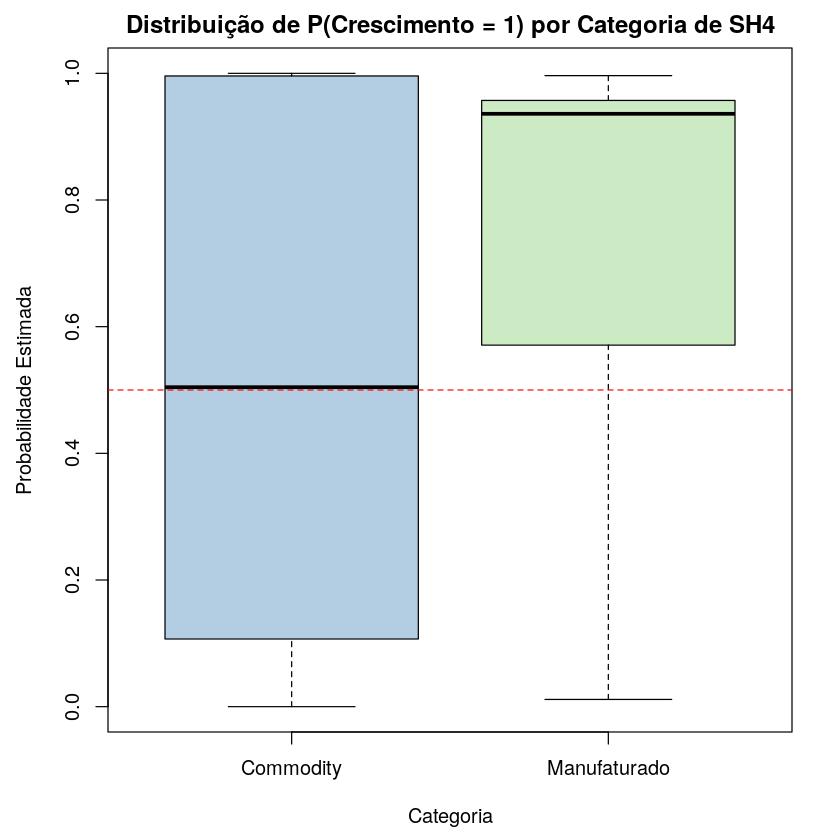

In [10]:
# Curva ROC e AUC do Modelo Múltiplo
auc_mult <- plotar_curva_roc(modelo_multiplo, dados_crescimento$Crescimento_binario, 
                             titulo = "ROC - Logística Múltipla (Crescimento FOB)")

# Boxplot de Probabilidades Estimadas por Categoria de Produto
dados_crescimento$prob_estimada <- predict(modelo_multiplo, type = "response")

boxplot(prob_estimada ~ Categoria_SH4, data = dados_crescimento,
        col = c("#B3CDE3", "#CCEBC5"),
        main = "Distribuição de P(Crescimento = 1) por Categoria de SH4",
        ylab = "Probabilidade Estimada", xlab = "Categoria")
abline(h = 0.5, lty = 2, col = "red")